# MLP: предсказание цены 

In [64]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.pytorch

from tqdm import tqdm

try:
    from torchinfo import summary
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "torchinfo"])
    from torchinfo import summary

pd.set_option("display.max_columns", None)

Часть полностью взятая из семинара, необходимая для дальнейшей работы:

In [65]:
# Зафиксируем seed для воспроизводимости

def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

In [66]:
class CFG:

# Задаем параметры нашего эксперимента
    seed             = 42
    test_size        = 0.2
    val_size         = 0.1
    batch_size       = 256
    num_epochs       = 30
    lr               = 1e-3
    target           = "price"
    drop_cols        = ["filename", "price"]
    mlflow_experiment = "GP5_MLP_price" # логер, экспреримент в mlflow


In [67]:
seed_everything(CFG.seed)

device = torch.device("cpu")

### Датасет

Работаем с предобработанным датасетом

In [68]:
df = pd.read_csv('./clothing_table_clean.csv')
df.head()

,filename,sizetext,stains,price,smell,price_confidence,condition,usage_confidence,comment,holes,colors,usage,type,damage,styleholes,image_type_back,brand,season_all_seasons,season_autumn,season_spring,season_winter,category_female,category_unisex
0,front_2023_09_13_05_18_15.png,0,1,27,2,3.0,2,3.0,0,0,3,1,14,0,0,0,1,1,0,0,0,1,0
1,front_2023_11_06_07_07_20.png,0,2,32,2,3.0,3,3.0,0,0,1,4,20,0,1,0,1,1,0,0,0,0,0
2,front_2023_06_29_13_15_53.png,0,1,21,2,3.0,3,1.0,0,0,2,1,14,0,0,0,1,1,0,0,0,0,0
3,back_2023_12_27_12_24_34.png,0,1,35,2,3.0,2,3.0,1,0,3,1,7,1,0,1,1,1,0,0,0,0,0
4,front_2023_12_21_12_28_39.png,0,1,67,2,3.0,5,3.0,1,0,1,5,20,0,0,0,0,1,0,0,0,0,0


### Работа с таргетом

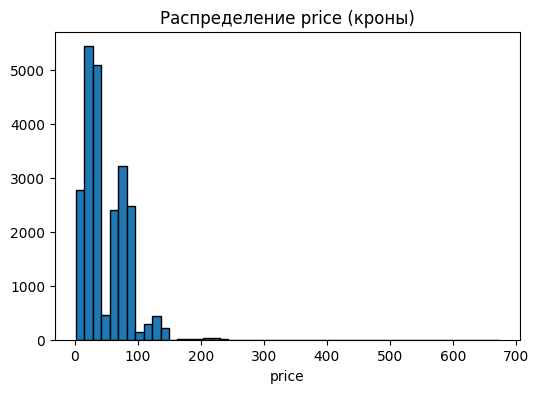

count    23081.000000
mean        48.971362
std         33.811598
min          2.000000
25%         23.000000
50%         37.000000
75%         74.000000
max        673.000000
Name: price, dtype: float64


In [69]:
fig, axes = plt.subplots(figsize=(6, 4))
axes.hist(df["price"], bins=50, edgecolor="black")
axes.set_title("Распределение price (кроны)")
axes.set_xlabel("price")

plt.show()

print(df["price"].describe())

Распределение price правостороннее, поэтому логарифмируем таргет для приближения к нормальному распределению, чтобы mlp лучше обучилась

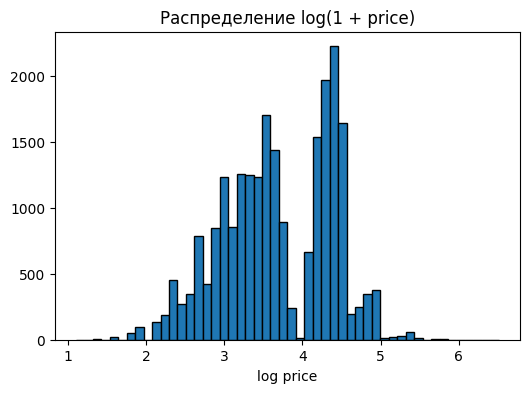

count    23081.000000
mean        48.971362
std         33.811598
min          2.000000
25%         23.000000
50%         37.000000
75%         74.000000
max        673.000000
Name: price, dtype: float64


In [70]:
fig, axes = plt.subplots(figsize=(6, 4))
axes.hist(np.log1p(df["price"]), bins=50, edgecolor="black")
axes.set_title("Распределение log(1 + price)")
axes.set_xlabel("log price")
plt.show()

print(df["price"].describe())

### train/val/test

In [71]:
y = np.log1p(df[CFG.target].values).astype(np.float32)
X = df.drop(columns=CFG.drop_cols).values.astype(np.float32)
feature_names = df.drop(columns=CFG.drop_cols).columns.tolist()

print(feature_names)

['sizetext', 'stains', 'smell', 'price_confidence', 'condition', 'usage_confidence', 'comment', 'holes', 'colors', 'usage', 'type', 'damage', 'styleholes', 'image_type_back', 'brand', 'season_all_seasons', 'season_autumn', 'season_spring', 'season_winter', 'category_female', 'category_unisex']


In [72]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=CFG.test_size, random_state=CFG.seed
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=CFG.val_size / (1 - CFG.test_size),
    random_state=CFG.seed,
)

Признаки в разных масштабах, поэтому нормализуем

In [73]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

train: (16156, 21) val: (2308, 21) test: (4617, 21)


Функция для упаковки данных для подачи в нейросеть батчами:

In [74]:
def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1)) # нужны двумерные вектора
    return DataLoader(ds, batch_size=CFG.batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

## Архитектуры

Три конфигурации:

1) Base - базовая, ReLU, без регуляризации
2) BN - с BatchNorm
3) BN_Dropout - с BatchNorm и Dropout (полная регуляризация)

(Dropout идёт после BatchNorm, иначе слои конфликтуют)

In [75]:
n_features = X_train.shape[1] # на вход

In [76]:
class Base(nn.Module):
    def __init__(self, n_features=n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [77]:
class BN(nn.Module):
    def __init__(self, n_features=n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        x = torch.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

In [78]:
class BN_Dropout(nn.Module):
    def __init__(self, n_features=n_features, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.do1 = nn.Dropout(p)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.do2 = nn.Dropout(p)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.do3 = nn.Dropout(p)
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.fc5 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.do1(torch.relu(self.bn1(self.fc1(x))))
        x = self.do2(torch.relu(self.bn2(self.fc2(x))))
        x = self.do3(torch.relu(self.bn3(self.fc3(x))))
        x = torch.relu(self.bn4(self.fc4(x)))
        return self.fc5(x)

Смотрим архитектуры

In [79]:
print("Base")
print(summary(Base(), input_size=(CFG.batch_size, n_features),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=18, verbose=0))

Base
Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
Base                                     [256, 21]          [256, 1]           --                 True
├─Linear: 1-1                            [256, 21]          [256, 128]         2,816              True
├─Linear: 1-2                            [256, 128]         [256, 64]          8,256              True
├─Linear: 1-3                            [256, 64]          [256, 1]           65                 True
Total params: 11,137
Trainable params: 11,137
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.85
Input size (MB): 0.02
Forward/backward pass size (MB): 0.40
Params size (MB): 0.04
Estimated Total Size (MB): 0.46


In [80]:
print("BN")
print(summary(BN(), input_size=(CFG.batch_size, n_features),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=18, verbose=0))

BN
Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
BN                                       [256, 21]          [256, 1]           --                 True
├─Linear: 1-1                            [256, 21]          [256, 256]         5,632              True
├─BatchNorm1d: 1-2                       [256, 256]         [256, 256]         512                True
├─Linear: 1-3                            [256, 256]         [256, 128]         32,896             True
├─BatchNorm1d: 1-4                       [256, 128]         [256, 128]         256                True
├─Linear: 1-5                            [256, 128]         [256, 64]          8,256              True
├─BatchNorm1d: 1-6                       [256, 64]          [256, 64]          128                True
├─Linear: 1-7                            [256, 64]          [256, 1]           65                 True
Total params: 47,745
Trainable params: 47,745
Non-trainable param

In [81]:
print("BN_Dropout")
print(summary(BN_Dropout(), input_size=(CFG.batch_size, n_features),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=18, verbose=0))

BN_Dropout
Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
BN_Dropout                               [256, 21]          [256, 1]           --                 True
├─Linear: 1-1                            [256, 21]          [256, 512]         11,264             True
├─BatchNorm1d: 1-2                       [256, 512]         [256, 512]         1,024              True
├─Dropout: 1-3                           [256, 512]         [256, 512]         --                 --
├─Linear: 1-4                            [256, 512]         [256, 256]         131,328            True
├─BatchNorm1d: 1-5                       [256, 256]         [256, 256]         512                True
├─Dropout: 1-6                           [256, 256]         [256, 256]         --                 --
├─Linear: 1-7                            [256, 256]         [256, 128]         32,896             True
├─BatchNorm1d: 1-8                       [256, 128]         [

Три архитектуры, каждая сложнее предыдущей
1) base: три линейных слоя, 11 тысяч параметров
2) BN: параметров стало 47 тысяч, BatchNorm нормализует выходы каждого слоя
3) BN_Dropout: почти 186 тысяч параметров на каждом шаге обучения случайно выключается 30% нейронов, чтобы такая большая сеть не переобучилась

## Обучение

Эпоха обучения:

In [82]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

Функция оценки модели на val или test:

In [83]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total_loss += criterion(pred, yb).item() * xb.size(0)
            preds_all.append(pred.cpu().numpy())
            targets_all.append(yb.cpu().numpy())
    return (
        total_loss / len(loader.dataset),
        np.vstack(preds_all).ravel(),
        np.vstack(targets_all).ravel(),
    )

Переводим предсказания из лог-шкалы обратно в реальные кроны (по анг кроны - sek)

In [84]:
def metrics_real_price(y_log, pred_log):
    y_real    = np.expm1(y_log)
    pred_real = np.expm1(pred_log)
    return {
        "MAE_sek":  mean_absolute_error(y_real, pred_real),
        "RMSE_sek": np.sqrt(mean_squared_error(y_real, pred_real)),
        "R2":       r2_score(y_real, pred_real),
    }

### Осталось запустить модели и залогировать

Один эксперимент для одной модели:

In [85]:
def run_experiment(model_cls, run_name, lr=CFG.lr, epochs=CFG.num_epochs):
    seed_everything(CFG.seed)
    model = model_cls().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "model": model_cls.__name__,
            "lr": lr,
            "batch_size": CFG.batch_size,
            "epochs": epochs,
            "in_dim": n_features,
            "n_params": sum(p.numel() for p in model.parameters()),
        })

        for epoch in range(1, epochs + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
            val_loss, val_pred, val_true = evaluate(model, val_loader, criterion)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)

            mlflow.log_metric("train_loss", train_loss, step=epoch) # логируем
            mlflow.log_metric("val_loss", val_loss, step=epoch)

            if val_loss < best_val:
                best_val   = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            if epoch % 5 == 0 or epoch == 1:
                print(f"epoch {epoch:02d}  train {train_loss:.4f}  val {val_loss:.4f}")

        # лучшие веса => финальные метрики на test
        model.load_state_dict(best_state)
        mlflow.pytorch.log_model(model, artifact_path="model")
        test_loss, test_pred, test_true = evaluate(model, test_loader, criterion)
        m = metrics_real_price(test_true, test_pred)

        mlflow.log_metric("test_loss_log", test_loss)
        for k, v in m.items():
            mlflow.log_metric(k, v)

        print(f"test loss(log)={test_loss:.4f}  MAE={m['MAE_sek']:.2f}  "
              f"RMSE={m['RMSE_sek']:.2f}  R2={m['R2']:.3f}")

    return model, history, m

# Запуск!!!

In [86]:
mlflow.set_experiment(CFG.mlflow_experiment)

results = {}

print("\nBase")
results["Base"] = run_experiment(Base, "base")

print("\nBN")
results["BN"] = run_experiment(BN, "bn")

print("\nBN_Dropout")
results["BN_Dropout"] = run_experiment(BN_Dropout, "bn_dropout")


Base


epoch 01  train 4.9772  val 0.4266
epoch 05  train 0.3225  val 0.3126
epoch 10  train 0.2952  val 0.2905
epoch 15  train 0.2834  val 0.2832
epoch 20  train 0.2781  val 0.2787
epoch 25  train 0.2728  val 0.2812


2026/06/15 23:49:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:49:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2708  val 0.2794
test loss(log)=0.2841  MAE=17.84  RMSE=27.07  R2=0.381

BN
epoch 01  train 7.9343  val 4.0479
epoch 05  train 0.2969  val 0.2993
epoch 10  train 0.2714  val 0.3043
epoch 15  train 0.2602  val 0.2938
epoch 20  train 0.2507  val 0.2882
epoch 25  train 0.2476  val 0.2959


2026/06/15 23:50:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:50:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2380  val 0.2893
test loss(log)=0.2856  MAE=17.60  RMSE=26.43  R2=0.410

BN_Dropout
epoch 01  train 7.3926  val 3.4065
epoch 05  train 0.3298  val 0.3054
epoch 10  train 0.3102  val 0.2939
epoch 15  train 0.2974  val 0.2843
epoch 20  train 0.2946  val 0.2860
epoch 25  train 0.2849  val 0.2775


2026/06/15 23:50:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:50:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2832  val 0.2785
test loss(log)=0.2739  MAE=17.82  RMSE=26.95  R2=0.387


# Сравнение архитектур

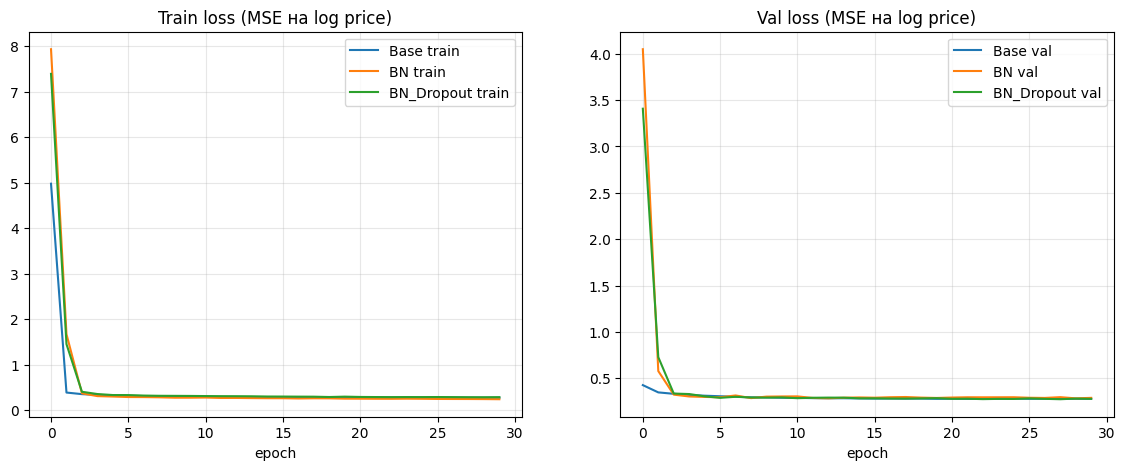

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (model, hist, m) in results.items():
    axes[0].plot(hist["train_loss"], label=f"{name} train")
    axes[1].plot(hist["val_loss"],   label=f"{name} val")

axes[0].set_title("Train loss (MSE на log price)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Val loss (MSE на log price)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

In [88]:
table = pd.DataFrame({
    name: m for name, (_, _, m) in results.items()
}).T
print(table.round(3))

            MAE_sek  RMSE_sek     R2
Base         17.843    27.071  0.381
BN           17.601    26.429  0.410
BN_Dropout   17.815    26.949  0.387


Все

In [89]:
os.makedirs("models", exist_ok=True)

for name, (model, _, _) in results.items():
    torch.save(model.state_dict(), f"models/mlp_{name}.pt")
    print(f"Сохранено: models/mlp_{name}.pt")

Сохранено: models/mlp_Base.pt
Сохранено: models/mlp_BN.pt
Сохранено: models/mlp_BN_Dropout.pt


# Лучшая

In [90]:
best_name = min(results, key=lambda k: results[k][2]["RMSE_sek"])
best_model = results[best_name][0]
print(f"Лучшая модель: {best_name}")

os.makedirs("models", exist_ok=True)
torch.save(best_model.state_dict(), f"models/mlp_best_{best_name}.pt")
print(f"Сохранено: models/mlp_best_{best_name}.pt")

Лучшая модель: BN
Сохранено: models/mlp_best_BN.pt


Попробуем подобрать lr для лучшей модели (BN)

In [91]:
for lr in [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]:
    _, _, m = run_experiment(BN, f"bn_lr_{lr}", lr=lr)
    print(f"  lr={lr}  MAE={m['MAE_sek']:.2f}  R2={m['R2']:.3f}")

epoch 01  train 13.6054  val 12.1855
epoch 05  train 7.5860  val 7.2670
epoch 10  train 3.8733  val 3.8180
epoch 15  train 1.5182  val 1.4545
epoch 20  train 0.5669  val 0.5879
epoch 25  train 0.3252  val 0.3423


2026/06/15 23:51:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:51:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2821  val 0.3116
test loss(log)=0.3121  MAE=19.66  RMSE=29.11  R2=0.284
  lr=0.0001  MAE=19.66  R2=0.284
epoch 01  train 10.2476  val 7.5693
epoch 05  train 0.4159  val 0.3404
epoch 10  train 0.2798  val 0.3064
epoch 15  train 0.2650  val 0.2940
epoch 20  train 0.2543  val 0.2885
epoch 25  train 0.2504  val 0.2962


2026/06/15 23:51:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:51:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2430  val 0.2895
test loss(log)=0.2871  MAE=18.06  RMSE=27.11  R2=0.380
  lr=0.0005  MAE=18.06  R2=0.380
epoch 01  train 7.9343  val 4.0479
epoch 05  train 0.2969  val 0.2993
epoch 10  train 0.2714  val 0.3043
epoch 15  train 0.2602  val 0.2938
epoch 20  train 0.2507  val 0.2882
epoch 25  train 0.2476  val 0.2959


...

epoch 30  train 0.2380  val 0.2893
test loss(log)=0.2856  MAE=17.60  RMSE=26.43  R2=0.410
  lr=0.001  MAE=17.60  R2=0.410
epoch 01  train 2.3446  val 0.3832
epoch 05  train 0.2894  val 0.2912
epoch 10  train 0.2719  val 0.2799
epoch 15  train 0.2588  val 0.2980
epoch 20  train 0.2552  val 0.2844
epoch 25  train 0.2487  val 0.2851


2026/06/15 23:52:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:52:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2367  val 0.2870
test loss(log)=0.2834  MAE=17.84  RMSE=26.78  R2=0.395
  lr=0.005  MAE=17.84  R2=0.395
epoch 01  train 1.5188  val 0.3353
epoch 05  train 0.2865  val 0.2904
epoch 10  train 0.2741  val 0.2834
epoch 15  train 0.2624  val 0.3011
epoch 20  train 0.2548  val 0.2949
epoch 25  train 0.2484  val 0.2929


2026/06/15 23:52:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 23:52:51 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


epoch 30  train 0.2392  val 0.2867
test loss(log)=0.2804  MAE=17.30  RMSE=26.01  R2=0.429
  lr=0.01  MAE=17.30  R2=0.429


# Что по выводам:

- Base — сходится быстро, но точность ниже всех
- BN — лучший результат по R2 и RMSE, BatchNorm стабилизирует обучение
- BN_Dropout — Dropout не помог, потому что модель и так не переобучалась на этих данных

Лучшая модель BN (R2=0.410). Средняя ошибка +-17 крон при средней цене 49 SEK. R²2 = 0.4 — модель объясняет около 40% вариации цены, остальные 60% — факторы которых нет в таблице (визуальная привлекательность, узнаваемость бренда)

Подбор lr для BN показал что lr=0.01 даёт лучший результат (R2=0.429, MAE=17.30)